In [15]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')# Added payments.csv for specific handling
]

# Connect to the MySQLconnect(
    host='localhost',
    user='root',
    password='8139',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/Roshni/Desktop/Ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

KeyboardInterrupt: 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "8139",
                             database = "ecommerce")
cur = db.cursor()


# LIST ALL UNIQUE CITIES WHERE CUSTOMERS ARE LOCATED.


In [30]:
query="""select distinct customer_city from customers"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df.head(5)

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# COUNT THE NUMBER OF ORDERS PLACED IN 2017.

In [14]:
query="""select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """
cur.execute(query)
data = cur.fetchall()
"total orders placed in the year 2017 are" ,data[0][0]

('total orders placed in the year 2017 are', 45101)

# Find the total sales per category

In [27]:
query="""select UPPER (products.product_category) category,
round(sum(payments.payment_value),2)
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id=order_items.order_id
group by category
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["Category","Sales"])
df.head(5)

,Category,Sales
0,PERFUMERY,1013477.32
1,FURNITURE DECORATION,2860352.78
2,TELEPHONY,973764.10
3,BED TABLE BATH,3425107.34
4,AUTOMOTIVE,1704588.66


# Calculate the percentage of orders that were paid in installments.

In [15]:
query="""select sum(case when payment_installments>=1 then 1
else 0 end)/count(*)*100 from payments
"""
cur.execute(query)
data = cur.fetchall()
"THE Percentage of Orders that were paid in Installments is" ,data[0][0]

('THE Percentage of Orders that were paid in Installments is',
 Decimal('99.9981'))

# Count number of customers from each state.

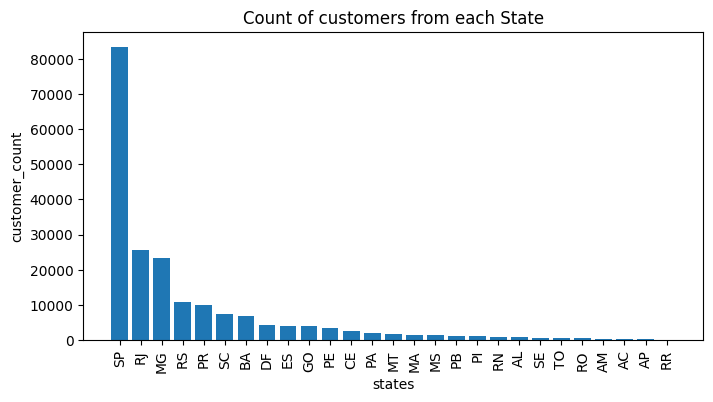

In [55]:
query="""select customer_state,count(customer_id) 
from customers
group by customer_state
"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["state","customer_count"])
df=df.sort_values(by="customer_count",ascending=False)
plt.figure(figsize=(8,4))
plt.bar(df["state"],df["customer_count"])
plt.xlabel("states")
plt.ylabel("customer_count")
plt.title("Count of customers from each State")
plt.xticks(rotation=90)
plt.show()

# Calculate the number of orders per month in 2018.

C:\Users\Roshni\AppData\Local\Temp\ipykernel_14204\3600498350.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["months"],y=df["order_count"],data=df,order=o,palette="spring")


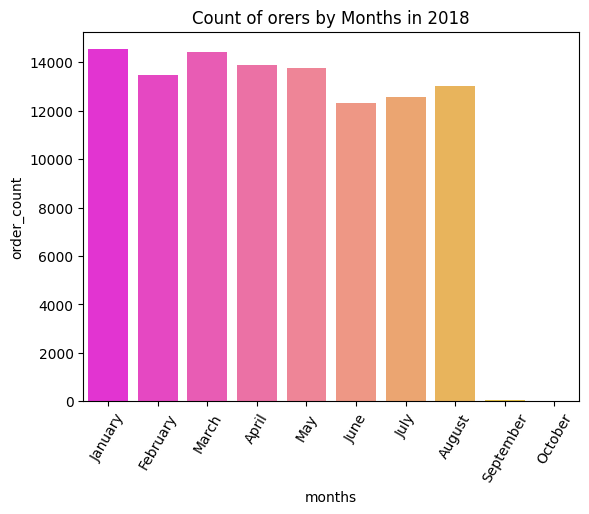

<Figure size 400x200 with 0 Axes>

In [4]:
query="""select monthname(order_purchase_timestamp) months,count(order_id) order_count
from orders where year(order_purchase_timestamp)=2018
group by months"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["months","order_count"])
o=["January","February","March","April","May","June","July","August","September","October"]
sns.barplot(x=df["months"],y=df["order_count"],data=df,order=o,palette="spring")
plt.xticks(rotation=60)
plt.title("Count of orers by Months in 2018")
plt.figure(figsize=(4,2))

plt.show()

# Find the average number of products per order, grouped by customer city.

In [12]:
query="""with count_per_order as
       (select  orders.order_id,orders.customer_id, count(order_items.order_id) as oc
        from orders join order_items
        on orders.order_id=order_items.order_id
        group by orders.order_id,orders.customer_id)
        
        select customers.customer_city,round(avg(count_per_order.oc),2)average_orders
        from customers join count_per_order
        on customers.customer_id=count_per_order.customer_id
        group by customers.customer_city order by average_orders desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["customer_city","avg_orders"])
df.head(10)

,customer_city,avg_orders
0,padre carvalho,14.00
1,celso ramos,13.00
2,datas,12.00
3,candido godoi,12.00
4,matias olimpio,10.00
5,cidelandia,8.00
6,curralinho,8.00
7,picarra,8.00
8,morro de sao paulo,8.00
9,teixeira soares,8.00


# Calculate the percentage of total revenue contributed by each product category.

In [24]:
query="""select UPPER (products.product_category) category,
(sum(payments.payment_value)/(select sum(payment_value)from payments))*100 sales
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id=order_items.order_id
group by category order by sales desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["category","sales"])

df.head(10)


,category,sales
0,BED TABLE BATH,21.395057
1,HEALTH BEAUTY,20.705683
2,COMPUTER ACCESSORIES,19.805648
3,FURNITURE DECORATION,17.867297
4,WATCHES PRESENT,17.855308
5,SPORT LEISURE,17.391951
6,HOUSEWARES,13.676893
7,AUTOMOTIVE,10.647775
8,GARDEN TOOLS,10.472702
9,COOL STUFF,9.740824


# Identify the correlation between product price and the number of times a product is purchased.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np
query="""select UPPER(products.product_category),
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id=order_items.product_id
group by products.product_category"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["categry","order_count","price"])

arr1=df["order_count"]
arr2=df["price"]
a=np.corrcoef([arr1,arr2])

print("The correlation is",a[0][1]) 

The correlation is -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.

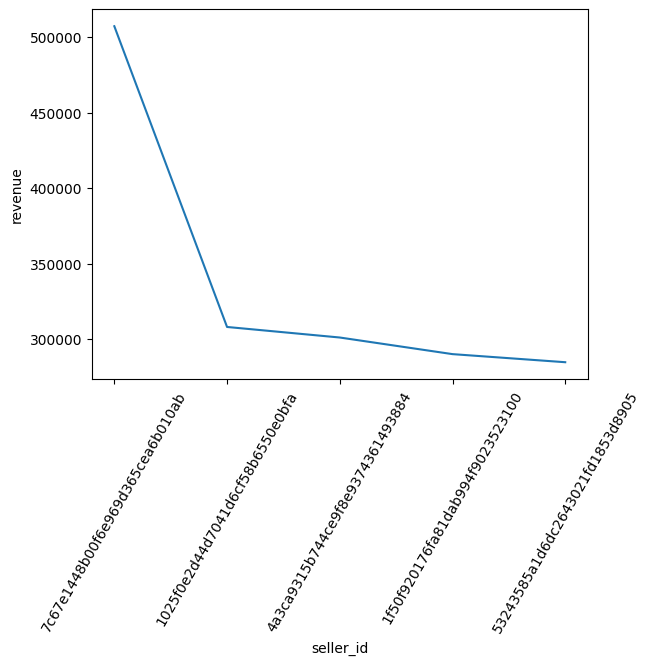

In [3]:
query="""select *, dense_rank() over(order by revenue desc)as rn from
(select order_items.seller_id, sum(payments.payment_value)
 revenue from  order_items join payments
on order_items.order_id=payments.order_id
group by  order_items.seller_id) as a"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["seller_id","revenue","rank"])
df=df.head()
sns.lineplot(x="seller_id",y="revenue",data=df)
plt.xticks(rotation=60)
plt.show()

# Calculate the moving average of order values for each 

In [8]:
query="""select customer_id,order_purchase_timestamp,payment,
avg(payment) over (partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row)as mov_avg
from
(select orders.customer_id,orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id=orders.order_id) as a"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["customer_id","order_purchase_time","payment","avg_payment"])
df.head(10)


,customer_id,order_purchase_time,payment,avg_payment
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
5,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
6,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
7,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
8,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
9,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002


# Calculate the cumulative sales per month for each year.

In [12]:
query="""select years,months,payment ,sum(payment)
over (order by years,months)  cumulative_sales from
(select  year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id=payments.order_id
group by years,months order by years,months) as a"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["years","months","payment","sum_payment"])
df.head(10)

,years,months,payment,sum_payment
0,2016,9,504.48,504.48
1,2016,10,118180.96,118685.44
2,2016,12,39.24,118724.68
3,2017,1,276976.08,395700.76
4,2017,2,583816.02,979516.78
5,2017,3,899727.20,1879243.98
6,2017,4,835576.06,2714820.04
7,2017,5,1185837.64,3900657.68
8,2017,6,1022552.76,4923210.44
9,2017,7,1184765.84,6107976.28


# Calculate the year-over-year growth rate of total sales.

In [23]:
query=""" with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id=payments.order_id
group by years order by years )
select years,((payment-lag(payment,1) over (order by years))/
lag(payment,1) over (order by years))*100 from a"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers,defined as the percentage of customers who makes another purchase within 6 months.

In [28]:
query="""with a as(select customers.customer_id,
min(orders.order_purchase_timestamp)first_order
from customers join orders
on customers.customer_id=orders.customer_id
group by customers.customer_id),

b as (select a.customer_id,count(distinct orders.order_purchase_timestamp)next_order
from a join orders
on orders.customer_id=a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id)

select 100*(count(distinct a.customer_id)/count(distinct b.customer_id))
from a left join b
on a.customer_id=b.customer_id"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df

,0
0,None


# Identify the top 3 Customers who spend the most money in each year.

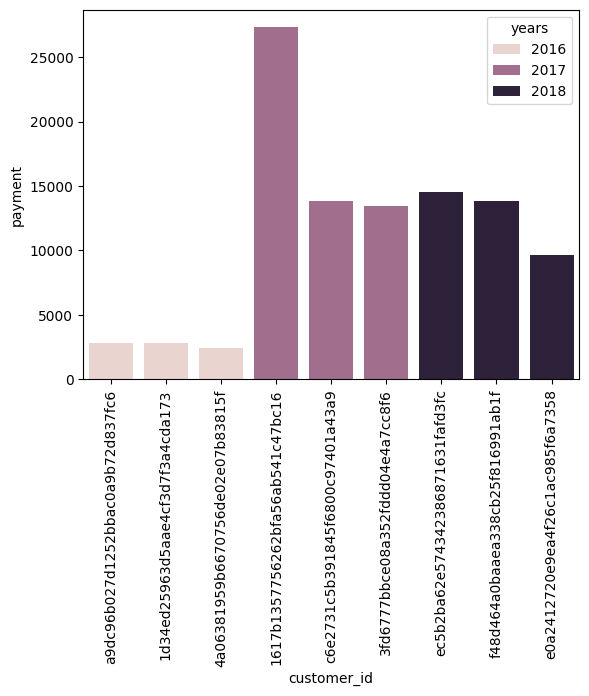

In [35]:
query="""select years,customer_id,payment,d_rank
from
(select year(orders.order_purchase_timestamp)years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id=orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank<=3"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["years","customer_id","payment","rank"])
sns.barplot(x="customer_id",y="payment",data=df,hue="years")
plt.xticks(rotation=90)
plt.show()

In [ ]:
"